In [1]:
# imports

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# imports for OLS / Anova
import statsmodels.formula.api as smf
import statsmodels.api as sm

# imports for function
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
pd.set_option('display.max_rows', 750)
pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', None)

In [3]:
# extract load

In [4]:
ls -lh ./data

total 13G
-rw-r--r-- 1 mijka mijka 166M 10 août   2022 clean_openfoodfacts_2.csv
-rw-r--r-- 1 mijka mijka 3,5M 12 avril 08:50 clean_openfoodfacts_3.csv
-rw-r--r-- 1 mijka mijka 166M  3 août   2022 clean_openfoodfacts.csv
-rw-r--r-- 1 mijka mijka 3,5M 31 mars  11:50 clean_openfoodfacts_x.csv
-rw-r--r-- 1 mijka mijka 5,6G 22 avril  2022 en.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 5,7G 22 avril  2022 fr.openfoodfacts.org.products.csv
-rw-r--r-- 1 mijka mijka 809M 21 avril  2017 fr.openfoodfacts.org.products_old.csv
-rw-r--r-- 1 mijka mijka 3,5M 31 mars  16:23 to_input_openfoodfacts.csv


In [5]:
path = './data/'
csv_path = path + 'clean_openfoodfacts_3.csv'
df = pd.read_csv(csv_path, low_memory=False)

In [6]:
df.rename(columns = {'energy-kcal_100g':'energy_kcal_100g'}, inplace=True)

In [7]:
df.head()

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640
1,000000001576,Pur jus de pomme,0.0,b,Beverages,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440
3,00000006,Riz au lait,4.0,c,Milk and dairy products,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048
4,00000038,Pizza prosciutto,5.0,c,Composite foods,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600


In [8]:
df.shape

(35707, 13)

In [9]:
df.describe()

,nutriscore_score,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
count,35707.000000,35707.000000,35707.000000,35707.000000,35707.000000,35707.000000,35707.000000,35707.000000,35707.000000
mean,8.661411,233.466527,14.057233,5.688581,10.661297,3.296270,12.846410,1.386287,0.560173
std,8.081851,154.737623,14.443105,7.695739,17.219795,6.472317,10.148118,1.966260,0.919628
min,-15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,118.000000,2.400000,0.600000,0.500000,0.200000,3.600000,0.200000,0.080000
50%,9.000000,206.000000,9.600000,2.600000,2.500000,0.800000,12.000000,1.000000,0.400000
75%,15.000000,338.000000,23.000000,8.400000,12.000000,3.000000,21.000000,1.800000,0.720000
max,35.000000,899.000000,99.900000,95.000000,99.000000,97.000000,99.000000,67.000000,44.000000


In [10]:
#missing data
df.isnull().sum()

code                  0
product_name          0
nutriscore_score      0
nutriscore_grade      0
pnns_groups_1         0
energy_kcal_100g      0
fat_100g              0
saturated-fat_100g    0
carbohydrates_100g    0
sugars_100g           0
proteins_100g         0
salt_100g             0
sodium_100g           0
dtype: int64

# Univariate analysis

In [11]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35707 entries, 0 to 35706
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   code                35707 non-null  object 
 1   product_name        35707 non-null  object 
 2   nutriscore_score    35707 non-null  float64
 3   nutriscore_grade    35707 non-null  object 
 4   pnns_groups_1       35707 non-null  object 
 5   energy_kcal_100g    35707 non-null  float64
 6   fat_100g            35707 non-null  float64
 7   saturated-fat_100g  35707 non-null  float64
 8   carbohydrates_100g  35707 non-null  float64
 9   sugars_100g         35707 non-null  float64
 10  proteins_100g       35707 non-null  float64
 11  salt_100g           35707 non-null  float64
 12  sodium_100g         35707 non-null  float64
dtypes: float64(9), object(4)
memory usage: 3.5+ MB


## Numerical variables

In [12]:
#num_cols = df.columns[df.dtypes == 'float64']
#num_cols

In [13]:
num_cols = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
energy_cols = ['energy_kcal_100g']
scores_cols = ['nutriscore_score', 'nutriscore_grade', 
               #'ecoscore_grade'
              ]

In [14]:
df.dtypes[df.dtypes == 'float64'].size

9

There's 9 numerical variables, that could be split into 2 groups regarding their different units of measurement / orders of magnitude :

- nutrients (less than 100g per 100g)
- energy (less than 900 Cal per 100g)

In [15]:
nutrients = ['fat_100g', 'saturated-fat_100g',
       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
       'sodium_100g']
energy = ['energy-kcal_100g']

##

fats = ['fat_100g', 'saturated-fat_100g']
sugars = ['carbohydrates_100g', 'sugars_100g']
other = ['proteins_100g', 'salt_100g',
       'sodium_100g']

In [16]:
def UVA_numeric2(data, i):
  '''
  Univariate_Analysis_numeric
  takes a group of variables (INTEGER and FLOAT) and plot/print all the descriptives and properties along with KDE.

  Runs a loop: calculate all the descriptives of i(th) variable and plot/print it
  '''
  # calculating descriptives of variable
  mini = data[i].min()
  maxi = data[i].max()
  ran = data[i].max()-data[i].min()
  mean = data[i].mean()
  median = data[i].median()
  st_dev = data[i].std()
  skew = data[i].skew()
  kurt = data[i].kurtosis()

  # calculating points of standard deviation
  points = mean-st_dev, mean+st_dev

  #Plotting the variable with every information
  sns.kdeplot(data[i], shade=True)
  sns.lineplot(points, [0,0], color = 'black', label = "std_dev")
  sns.scatterplot([mini,maxi], [0,0], color = 'orange', label = "min/max")
  sns.scatterplot([mean], [0], color = 'red', label = "mean")
  sns.scatterplot([median], [0], color = 'blue', label = "median")
  plt.xlabel('{}'.format(i), fontsize = 20)
  plt.ylabel('density')
  plt.title('std_dev = {}; kurtosis = {};\nskew = {}; range = {}\nmean = {}; median = {}'.format((round(points[0],2),round(points[1],2)),
                                                                                                   round(kurt,2),
                                                                                                   round(skew,2),
                                                                                                   (round(mini,2),round(maxi,2),round(ran,2)),
                                                                                                   round(mean,2),
                                                                                                   round(median,2)))

In [17]:
# afficher détail Boxplot / UVA_num pour chaque indicateur par ligne

def UVA_num_plus(df, indicators_list):
  
    for i in indicators_list:
        plt.figure(figsize = (15, 20))
        df_indic = df[i]

        plt.subplot(5,2,1)
        sns.boxplot(y=df_indic)
        plt.xlabel(f'{i}', fontsize = 20)


        plt.subplot(5,2,2)
        UVA_numeric2(df, i)


In [18]:
# distributions du data set "cleané"

[Text(0, 0, 'fat_100g'),
 Text(1, 0, 'saturated-fat_100g'),
 Text(2, 0, 'carbohydrates_100g'),
 Text(3, 0, 'sugars_100g'),
 Text(4, 0, 'proteins_100g'),
 Text(5, 0, 'salt_100g'),
 Text(6, 0, 'sodium_100g')]

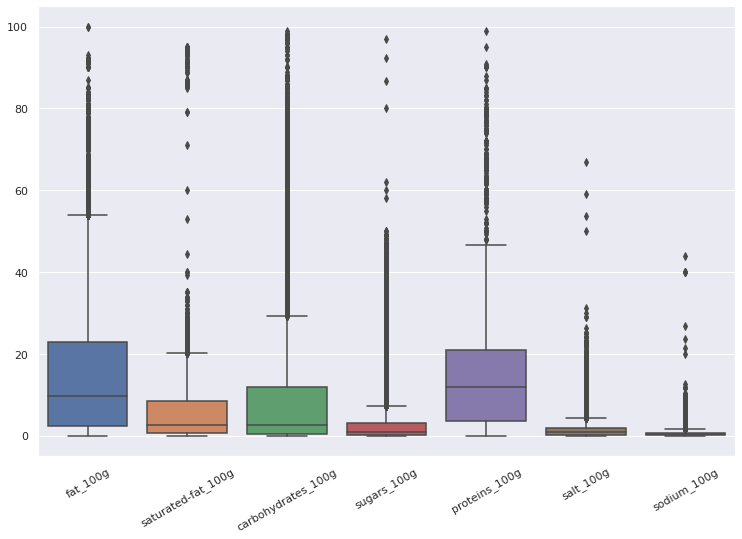

In [19]:
sns.set(rc={'figure.figsize':(12.5,8.27)})
ax = sns.boxplot(data=df[num_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

[Text(0, 0, 'energy_kcal_100g')]

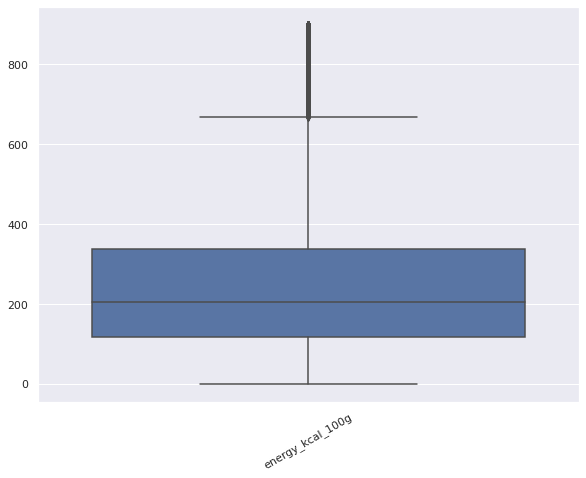

In [20]:
sns.set(rc={'figure.figsize':(9.7,7.27)})
ax = sns.boxplot(data=df[energy_cols])
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)

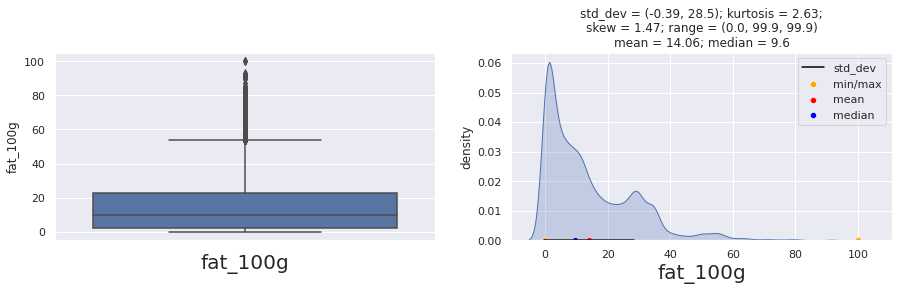

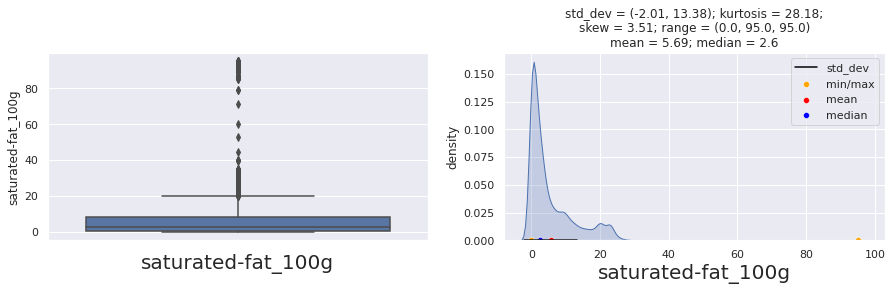

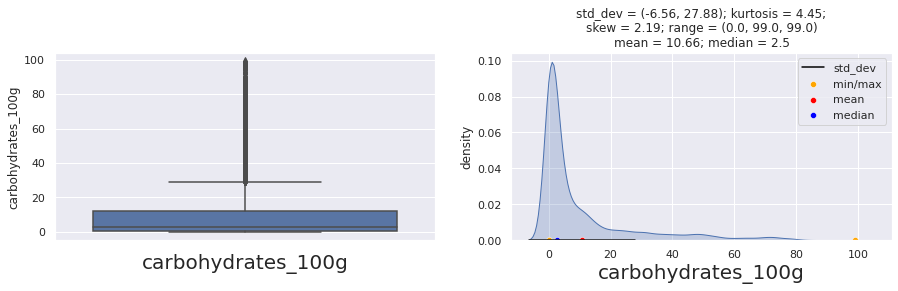

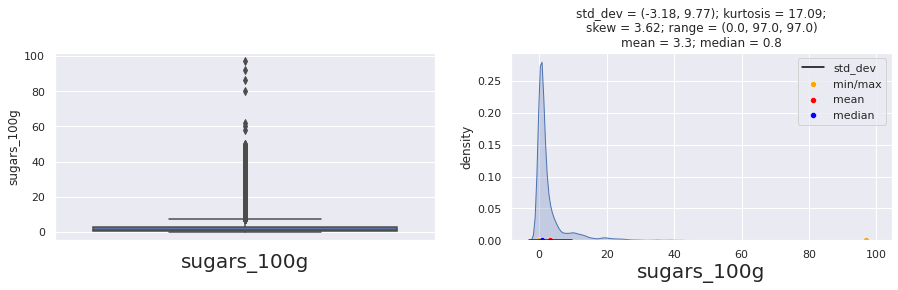

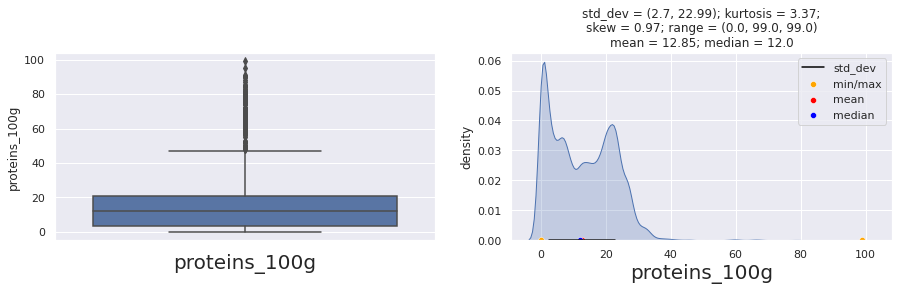

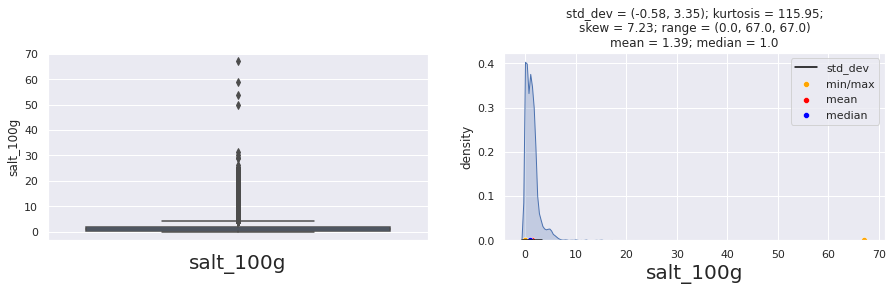

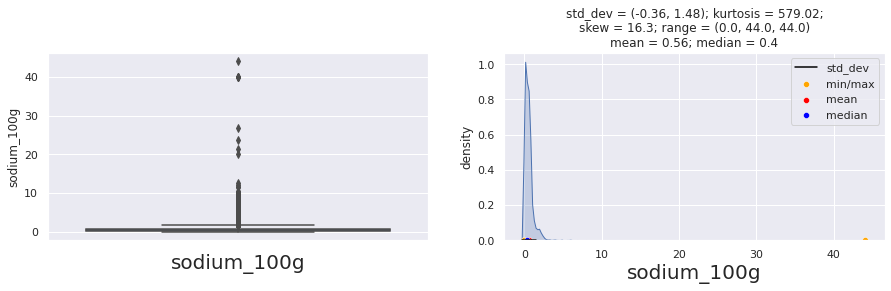

In [21]:
UVA_num_plus(df, num_cols)

### Comparison with univariates from un-cleaned data source

In [22]:
#old_path = path + 'fr.openfoodfacts.org.products.csv'
#columns = ['product_name', 'pnns_groups_1', 'pnns_groups_2', 'code',
#        'fat_100g', 'saturated-fat_100g',
#       'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g',
#       'sodium_100g']

In [23]:
#df_old = pd.read_csv(old_path, sep='\t', header='infer', on_bad_lines='skip', low_memory=False)

In [24]:
#df_old = df_old[columns]

In [25]:
#df_old.shape

In [26]:
#old_num_cols = df_old.columns[df_old.dtypes == 'float64']
#old_num_cols

In [27]:
# ce sont les distributions du data set initial !!!

#UVA_num_plus(df_old, old_num_cols)

## Categorical variables

In [28]:
mylist = df['pnns_groups_1'].unique()
mylist

array(['Salty snacks', 'Beverages', 'Milk and dairy products',
       'Composite foods', 'Fat and sauces', 'Cereals and potatoes',
       'Fish Meat Eggs', 'Sugary snacks', 'Fruits and vegetables',
       'Alcoholic beverages'], dtype=object)

In [29]:
n =10

newlist = mylist[:n]
newlist

array(['Salty snacks', 'Beverages', 'Milk and dairy products',
       'Composite foods', 'Fat and sauces', 'Cereals and potatoes',
       'Fish Meat Eggs', 'Sugary snacks', 'Fruits and vegetables',
       'Alcoholic beverages'], dtype=object)

In [30]:
cats = ['pnns_groups_1', 'pnns_groups_2']

In [31]:
# Custom function for easy visualisation of Categorical Variables
def UVA_category(data, var_group, width=7, height=5):

  '''
  Univariate_Analysis_categorical
  takes a group of variables (category) and plot/print all the value_counts and barplot.
  '''
  # setting figure_size
  size = len(var_group)
  plt.figure(figsize = (width*size, height), dpi = 100)

  # for every variable
  for j,i in enumerate(var_group):
    norm_count = data[i].value_counts(normalize = True)
    n_uni = data[i].nunique()

  #Plotting the variable with every information
    plt.subplot(1,size,j+1)
    sns.barplot(norm_count, norm_count.index , order = norm_count.index)
    plt.xlabel('fraction/percent', fontsize = 20)
    plt.ylabel('{}'.format(i), fontsize = 20)
    plt.title('n_uniques = {} \n value counts \n {};'.format(n_uni,norm_count))

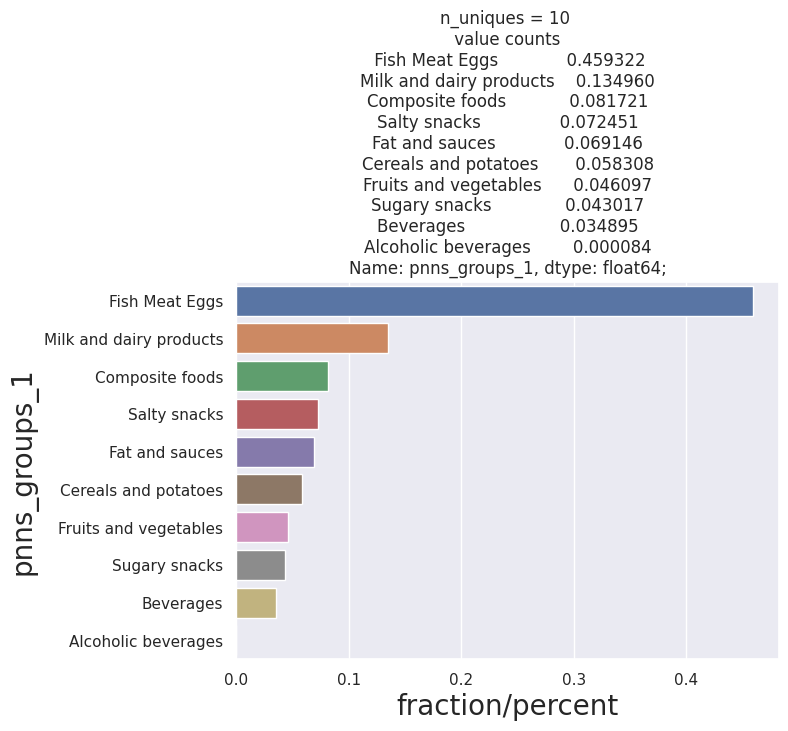

In [32]:
pd.set_option('display.max_rows', 10)
UVA_category(df, ['pnns_groups_1'])

In [33]:
df['pnns_groups_1'].value_counts()

Fish Meat Eggs             16401
Milk and dairy products     4819
Composite foods             2918
Salty snacks                2587
Fat and sauces              2469
Cereals and potatoes        2082
Fruits and vegetables       1646
Sugary snacks               1536
Beverages                   1246
Alcoholic beverages            3
Name: pnns_groups_1, dtype: int64

### pie charts

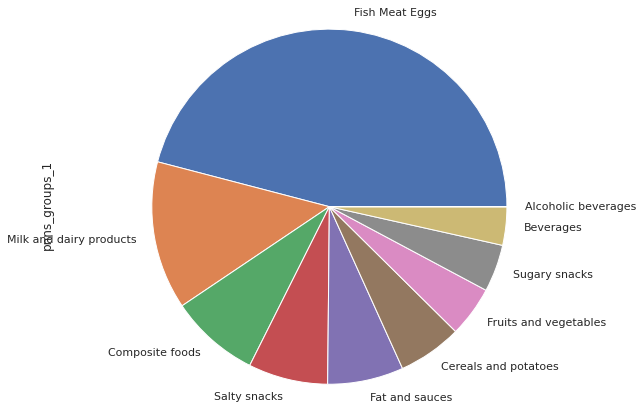

In [34]:
# Diagramme en secteurs
#sns.set(font_scale=1.2)
df['pnns_groups_1'].value_counts(normalize=True).plot(kind='pie')
plt.axis('equal')
plt.show()

In [35]:
#colors = sns.color_palette('pastel')[0:5]

#plt.pie(df['pnns_groups_2'], colors = colors, autopct='%.0f%%')
#plt.show()

# Bi-variate

=> ajouter graphs num / num & cat/cat & num/cat

In [36]:
df.head()

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640
1,000000001576,Pur jus de pomme,0.0,b,Beverages,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440
3,00000006,Riz au lait,4.0,c,Milk and dairy products,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048
4,00000038,Pizza prosciutto,5.0,c,Composite foods,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600


In [37]:
# cat / num

In [38]:
x = df['pnns_groups_1']
y = df['energy_kcal_100g']

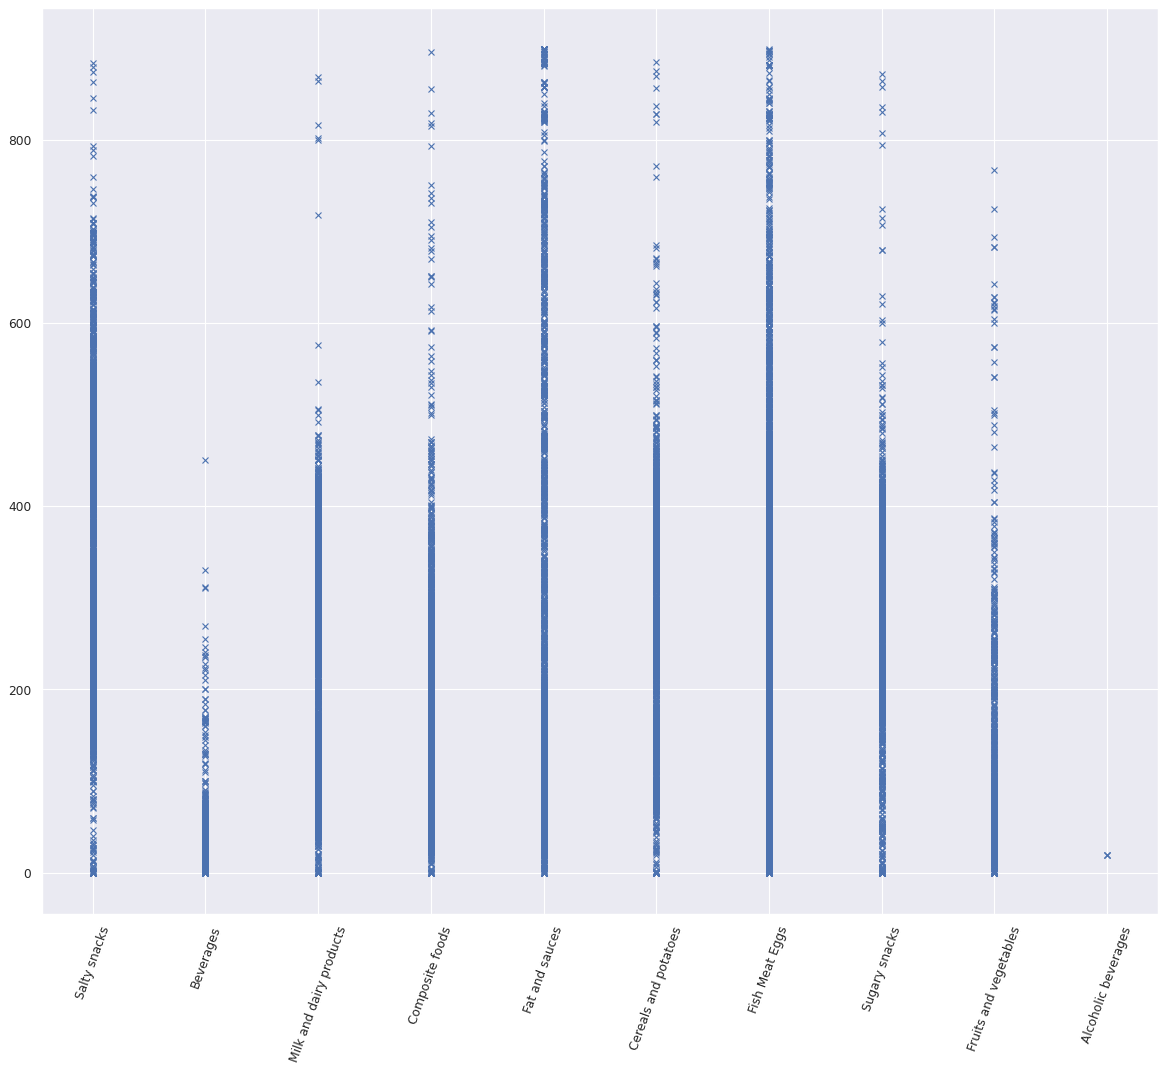

In [39]:
plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
plt.plot(x, y, 'x')
plt.show()

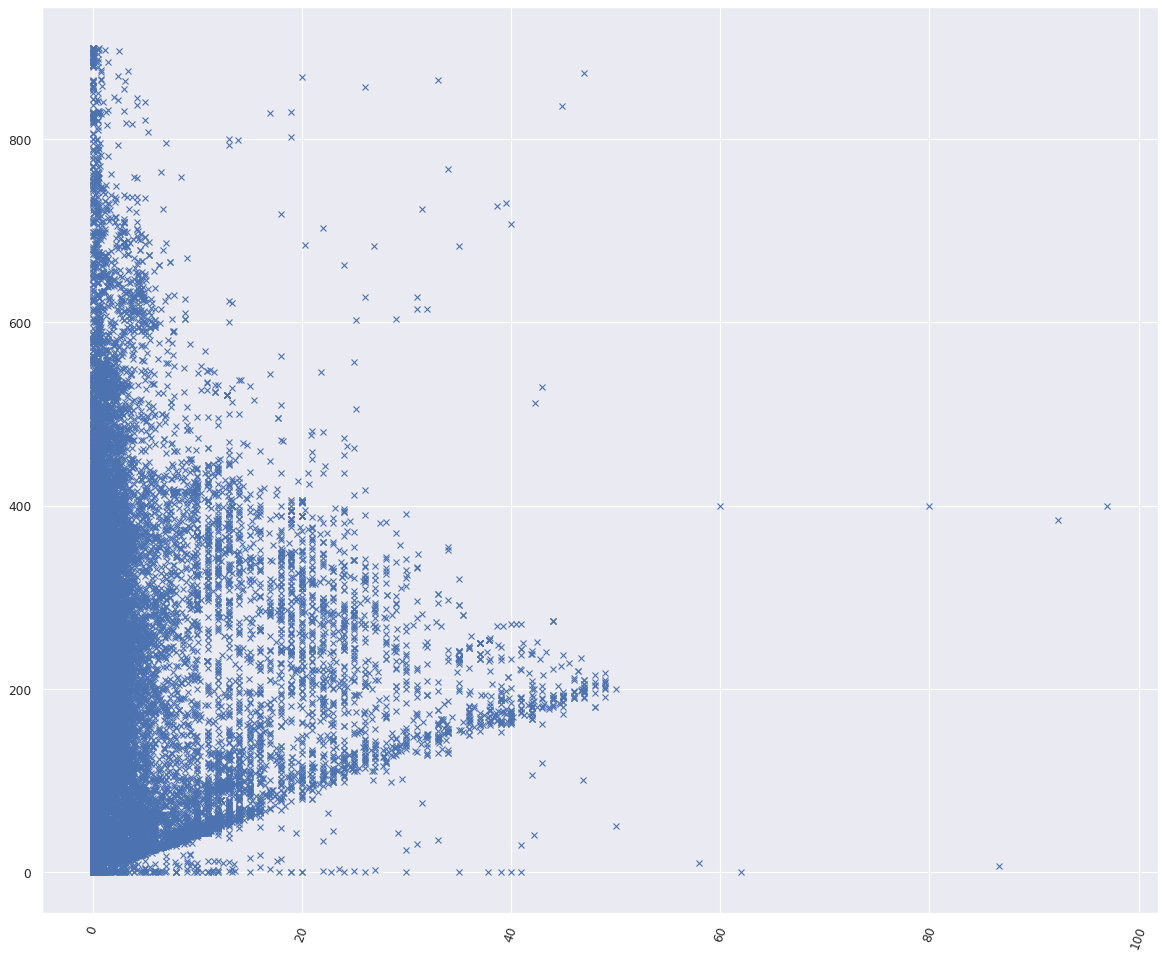

In [40]:
# num / num

plt.figure(figsize=(18, 15), dpi=80)
plt.xticks(rotation=70)
x = df['sugars_100g']
y = df['energy_kcal_100g']
plt.plot(x,y, 'x')
plt.show()
# titres
#taille

# Multi-variate


## Correlation Matrix

In [41]:
num_cols

['fat_100g',
 'saturated-fat_100g',
 'carbohydrates_100g',
 'sugars_100g',
 'proteins_100g',
 'salt_100g',
 'sodium_100g']

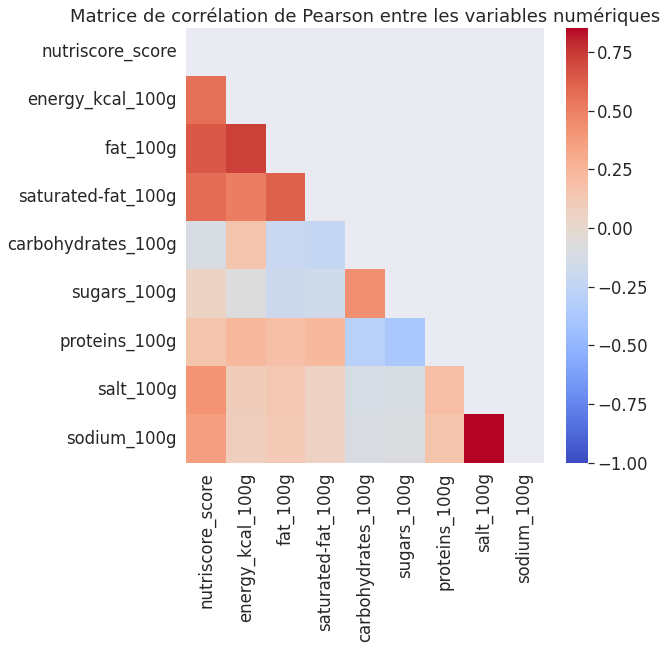

In [42]:
plt.figure(figsize=(8,8))
sns.set(font_scale=1.5)
plt.title('Matrice de corrélation de Pearson entre les variables numériques')

corr = df.corr()

mask = np.zeros_like(corr, dtype=np.bool_)
mask[np.triu_indices_from(mask)] = True 

ax = sns.heatmap(corr, mask=mask, vmin=-1, cmap='coolwarm')
plt.show()
sns.set(font_scale=1)

On peut retirer du tableau les informations suivantes :

- **fat_100g** et **saturated-fat_100g** sont fortement corrélés
- **energy-kcal_100g** : forte corrélation avec :
  - fat_100g
  - saturated-fat_100g
  - carbohydrates_100g
  - proteins_100g
- **sodium_100g** et **salt_100g** sont fortement corrélés
- **sugars_100g** sont corrélés avec **carbohydrates_100g**

## Hierarchical clustering / CHA (Classification Hiérarchique Ascendante)

In [43]:
# Sur le P3, j'ai rajouté ce matin un CHA pour voir plus facilement les relations 
# entre les différents éléments numériques

In [44]:
num_cols = df.columns[df.dtypes == 'float64']
num_cols

Index(['nutriscore_score', 'energy_kcal_100g', 'fat_100g',
       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
       'proteins_100g', 'salt_100g', 'sodium_100g'],
      dtype='object')

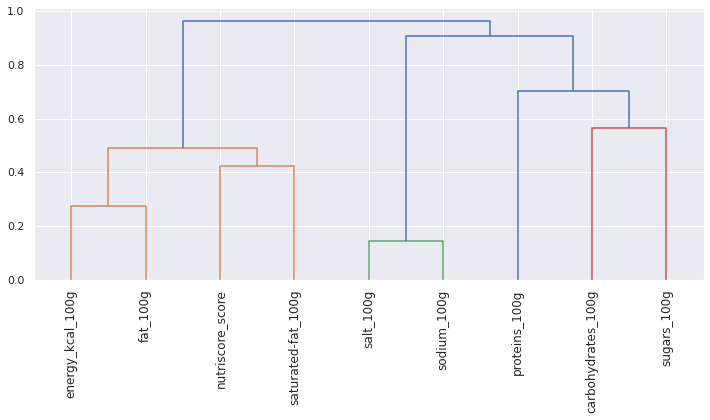

In [45]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import squareform

plt.figure(figsize=(12,5))
dissimilarity = 1 - abs(corr)
Z = linkage(squareform(dissimilarity), 'complete')

dendrogram(Z, 
           labels=num_cols, 
           orientation='top', 
           leaf_rotation=90
          );

# Multi-variate analysis

##  Analyse de la variance (ANOVA)

In [46]:
# normalisation / régularisation skewness avant Anova : utiliser le LOG

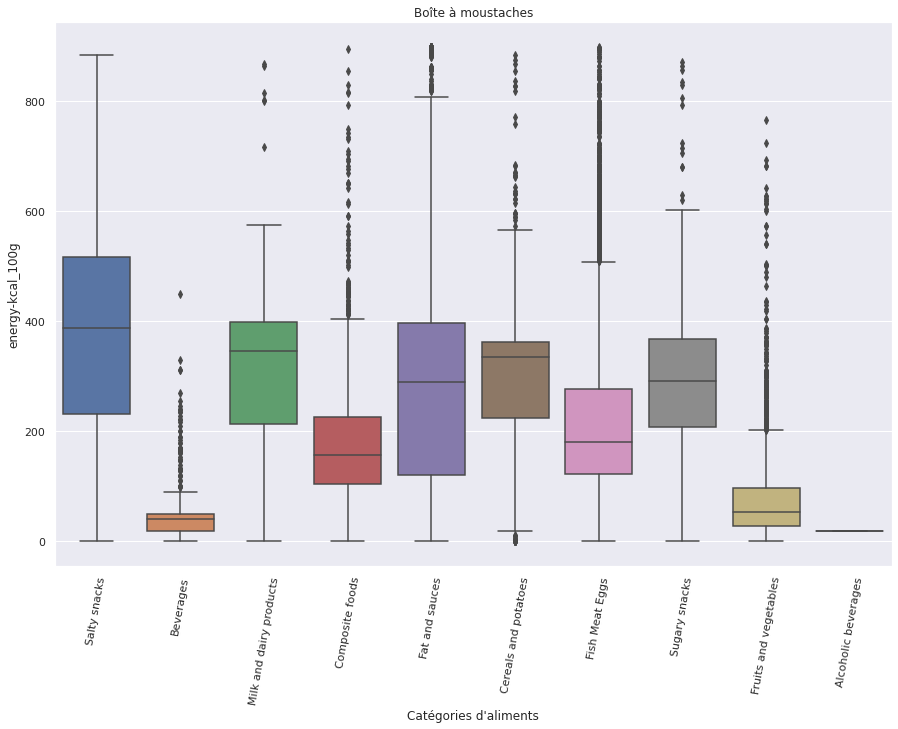

In [47]:
sns.set()
plt.figure(figsize = (15, 10))
plt.xticks(rotation=80)
ax = sns.boxplot(x='pnns_groups_1', y='energy_kcal_100g', data=df)
plt.xlabel("Catégories d'aliments")
plt.ylabel('energy-kcal_100g')
plt.title('Boîte à moustaches')
plt.show()

Les 12 catégories semblent différentes, il faut maintenant voir si les écarts sont significatifs ou pas grâce à l'ANOVA

=>  interpreting OLS summary results :

- [link1](https://statisticsbyjim.com/regression/interpret-coefficients-p-values-regression/)
- [link2](https://www.geeksforgeeks.org/interpreting-the-results-of-linear-regression-using-ols-summary/)
- [link3](https://jyotiyadav99111.medium.com/statistics-how-should-i-interpret-results-of-ols-3bde1ebeec01)



In [48]:
# standard scale before anova ?

In [49]:
anova_category_nrj = smf.ols('energy_kcal_100g~pnns_groups_1', data=df).fit()
print(anova_category_nrj.summary())

                            OLS Regression Results                            
Dep. Variable:       energy_kcal_100g   R-squared:                       0.227
Model:                            OLS   Adj. R-squared:                  0.227
Method:                 Least Squares   F-statistic:                     1165.
Date:                Wed, 19 Apr 2023   Prob (F-statistic):               0.00
Time:                        09:15:41   Log-Likelihood:            -2.2609e+05
No. Observations:               35707   AIC:                         4.522e+05
Df Residuals:                   35697   BIC:                         4.523e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Tableau de l'analyse de la variance :

In [50]:
sm.stats.anova_lm(anova_category_nrj, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_1,1.940776e+08,9.0,1164.814982,0.0
Residual,6.608573e+08,35697.0,NaN,NaN


In [51]:
anova_category_fat = smf.ols('fat_100g~pnns_groups_1', data=df).fit()
print(anova_category_fat.summary())

                            OLS Regression Results                            
Dep. Variable:               fat_100g   R-squared:                       0.276
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1509.
Date:                Wed, 19 Apr 2023   Prob (F-statistic):               0.00
Time:                        09:15:41   Log-Likelihood:            -1.4025e+05
No. Observations:               35707   AIC:                         2.805e+05
Df Residuals:                   35697   BIC:                         2.806e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

Tableau d'analyse de la variance :

In [52]:
sm.stats.anova_lm(anova_category_fat, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_1,2.053101e+06,9.0,1509.332247,0.0
Residual,5.395288e+06,35697.0,NaN,NaN


In [53]:
anova_category2_nrj = smf.ols('salt_100g~pnns_groups_1', data=df).fit()
print(anova_category2_nrj.summary())

                            OLS Regression Results                            
Dep. Variable:              salt_100g   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     201.2
Date:                Wed, 19 Apr 2023   Prob (F-statistic):               0.00
Time:                        09:15:41   Log-Likelihood:                -73925.
No. Observations:               35707   AIC:                         1.479e+05
Df Residuals:                   35697   BIC:                         1.480e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                               coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------

In [54]:
sm.stats.anova_lm(anova_category2_nrj, typ=2)

,sum_sq,df,F,PR(>F)
pnns_groups_1,6663.915146,9.0,201.179395,0.0
Residual,131381.788760,35697.0,NaN,NaN


## PCA

In [55]:
#features = df.columns[df.dtypes == 'float64']
#features

In [56]:
#features.size

In [57]:
# toutes features
# transformer variables categorielles en nombres (ex : ordinalEncoder +++ / OneHotEncoder)


In [58]:
df_nutri = df[['nutriscore_score', 'nutriscore_grade']].copy()

In [59]:
dfc = df.copy()

In [60]:
dfc.drop(columns=['product_name', 'code', 'nutriscore_score', 'nutriscore_grade'], inplace=True)

In [61]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35707 entries, 0 to 35706
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   pnns_groups_1       35707 non-null  object 
 1   energy_kcal_100g    35707 non-null  float64
 2   fat_100g            35707 non-null  float64
 3   saturated-fat_100g  35707 non-null  float64
 4   carbohydrates_100g  35707 non-null  float64
 5   sugars_100g         35707 non-null  float64
 6   proteins_100g       35707 non-null  float64
 7   salt_100g           35707 non-null  float64
 8   sodium_100g         35707 non-null  float64
dtypes: float64(8), object(1)
memory usage: 2.5+ MB


In [62]:
energy_cols

['energy_kcal_100g']

In [63]:
## enlever product_name & code

In [64]:
dfc[energy_cols].head()

,energy_kcal_100g
0,325.0
1,221.0
2,25.0
3,150.0
4,197.0


In [65]:
# encoding categories
from sklearn.preprocessing import OrdinalEncoder

enc = OrdinalEncoder()
dfc[energy_cols] = enc.fit_transform(dfc[energy_cols])

In [66]:
dfc.head()

,pnns_groups_1,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,Salty snacks,798.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640
1,Beverages,610.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004
2,Salty snacks,123.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440
3,Milk and dairy products,455.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048
4,Composite foods,566.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600


In [67]:
def clean_data(data, select_X=None, impute=False, std=False): 
    """Returns dataframe with selected, imputed 
       and standardized features
    
    Input
          data: dataframe
          select_X: list of feature names to be selected (string)
          impute: If True impute np.nan with mean
          std: If True standardize data
          
    Return
        dataframe: data with selected, imputed 
                   and standardized features    
    """
    
    # (i.) select features
    if select_X is not None:
        data = data.filter(select_X, axis='columns')
        print("\t>>> Selected features: {}".format(select_X))
    else:
        # store column names
        select_X = list(data.columns)
    
    # (ii.) impute with mean 
    if impute:
        imp = SimpleImputer()
        data = imp.fit_transform(data)
        print("\t>>> Imputed missings")
    
    # (iii.) standardize 
    if std:
        std_scaler = StandardScaler()
        data = std_scaler.fit_transform(data)
        print("\t>>> Standardized data")
    
    return pd.DataFrame(data, columns=select_X)

#  (iv.) select relevant features 
selected_features = [
    'energy_kcal_100g', 
    'fat_100g',
      'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
                     'proteins_100g', 'salt_100g', 'sodium_100g']
#selected_features = [num_cols] + [energy_cols] 
#+ ['nutriscore']
# (v.) select features, impute missings and standardize
X_std = clean_data(dfc, selected_features, impute=False, std=True)

	>>> Selected features: ['energy_kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']
	>>> Standardized data


In [68]:
#selected_features = ['pnns_groups_1', 'pnns_groups_2', 'energy_kcal_100g', 'fat_100g',
#       'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g',
#       'proteins_100g', 'salt_100g', 'sodium_100g']

In [69]:
X_std.head()

,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g
0,0.726652,1.034610,0.690186,-0.619139,-0.509295,0.310761,0.108692,0.086805
1,0.067148,-0.938678,-0.726202,-0.618558,-0.507749,-1.216638,-0.699962,-0.604789
2,-1.641249,1.986634,1.505584,-0.591554,-0.497707,0.020062,-0.145602,-0.130678
3,-0.476593,-0.606335,-0.297387,0.658478,1.499288,-0.940721,-0.644017,-0.556943
4,-0.087204,-0.647878,-0.362359,0.832699,-0.184831,-0.181949,0.057833,0.043308


In [70]:
X_std.shape[1]

8

In [71]:
# Initialize PCA
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_std)

PCA()

In [72]:
# Get basic info
n_components = len(pca.explained_variance_ratio_)
explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
idx = np.arange(n_components)+1
df_explained_variance = pd.DataFrame([explained_variance, cum_explained_variance], 
                                     index=['explained variance', 'cumulative'], 
                                     columns=idx).T

mean_explained_variance = df_explained_variance.iloc[:,0].mean() # calculate mean explained variance# 


# Print explained variance as plain text
print('Résumé PCA')
print('='*40)
print("Total: {} composants".format(n_components))
print('-'*40)
print('Moyenne de la variance expliquée :', round(mean_explained_variance,3))
print('-'*40)
print(df_explained_variance.head(20))
print('-'*40)

Résumé PCA
Total: 8 composants
----------------------------------------
Moyenne de la variance expliquée : 0.125
----------------------------------------
   explained variance  cumulative
1            0.337114    0.337114
2            0.220610    0.557724
3            0.184303    0.742027
4            0.099855    0.841882
5            0.071970    0.913852
6            0.049311    0.963163
7            0.018825    0.981988
8            0.018012    1.000000
----------------------------------------


Le 1er composant représente 25% de la variance.

Si l'on veut réduire les dimensions existantes et retenir 93% de la variance originale, on peut rester sur 7 composants.


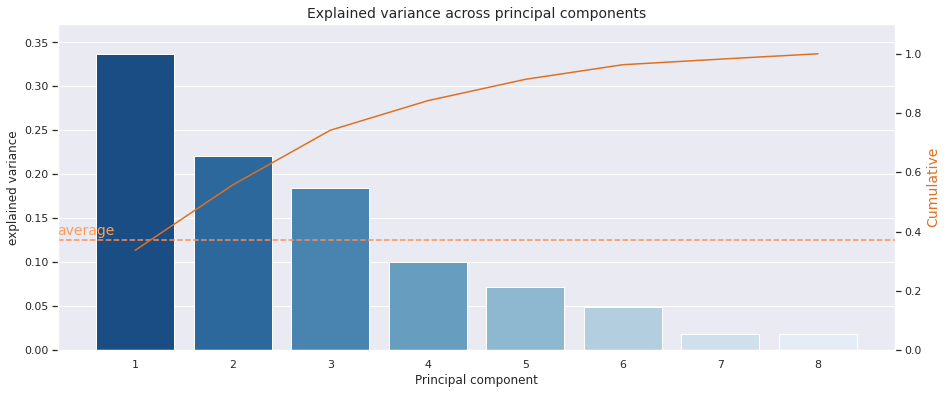

In [73]:
# limit plot to x PC
#limit = int(input("Limit scree plot to nth component (0 for all) > "))
limit = 0
if limit > 0:
    limit_df = limit
else:
    limit_df = n_components
    
df_explained_variance_limited = df_explained_variance.iloc[:limit_df,:]
    
    
# make scree plot
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.set_title('Explained variance across principal components', fontsize=14)
ax1.set_xlabel('Principal component', fontsize=12)
ax1.set_ylabel('Explained variance', fontsize=12)

ax2 = sns.barplot(x=idx[:limit_df], y='explained variance', data=df_explained_variance_limited, palette='Blues_r')
ax2 = ax1.twinx()
ax2.grid(False)
ax2.set_ylabel('Cumulative', fontsize=14, color='#de7021')
ax2 = sns.lineplot(x=idx[:limit_df]-1, y='cumulative', data=df_explained_variance_limited, color='#de7021')

ax1.axhline(mean_explained_variance, ls='--', color='#fc8d59') 

#plot mean
ax1.text(-.8, mean_explained_variance+(mean_explained_variance*.05), "average", color='#fc9d59', fontsize=14)


# label y axis
max_y1 = max(df_explained_variance_limited.iloc[:,0])
max_y2 = max(df_explained_variance_limited.iloc[:,1])
ax1.set(ylim=(0, max_y1+max_y1*.1))
ax2.set(ylim=(0, max_y2+max_y2*.1))
plt.show()

In [74]:
# https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html#sklearn.decomposition.PCA.get_feature_names_out

#get_feature_names_out(input_features=None)[source]

In [ ]:
# test PCA with non-scaled data..

In [79]:
X_std_2 = clean_data(dfc, selected_features, impute=False, std=False)

	>>> Selected features: ['energy_kcal_100g', 'fat_100g', 'saturated-fat_100g', 'carbohydrates_100g', 'sugars_100g', 'proteins_100g', 'salt_100g', 'sodium_100g']


In [82]:
pca2 = PCA()
pca2.fit(X_std_2)

PCA()

In [83]:
# Get basic info
n_components = len(pca2.explained_variance_ratio_)
explained_variance = pca2.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
idx = np.arange(n_components)+1
df_explained_variance = pd.DataFrame([explained_variance, cum_explained_variance], 
                                     index=['explained variance', 'cumulative'], 
                                     columns=idx).T

mean_explained_variance = df_explained_variance.iloc[:,0].mean() # calculate mean explained variance# 


# Print explained variance as plain text
print('Résumé PCA')
print('='*40)
print("Total: {} composants".format(n_components))
print('-'*40)
print('Moyenne de la variance expliquée :', round(mean_explained_variance,3))
print('-'*40)
print(df_explained_variance.head(20))
print('-'*40)

Résumé PCA
Total: 8 composants
----------------------------------------
Moyenne de la variance expliquée : 0.125
----------------------------------------
   explained variance  cumulative
1            0.993036    0.993036
2            0.004280    0.997316
3            0.001266    0.998582
4            0.000622    0.999203
5            0.000392    0.999596
6            0.000350    0.999946
7            0.000052    0.999998
8            0.000002    1.000000
----------------------------------------


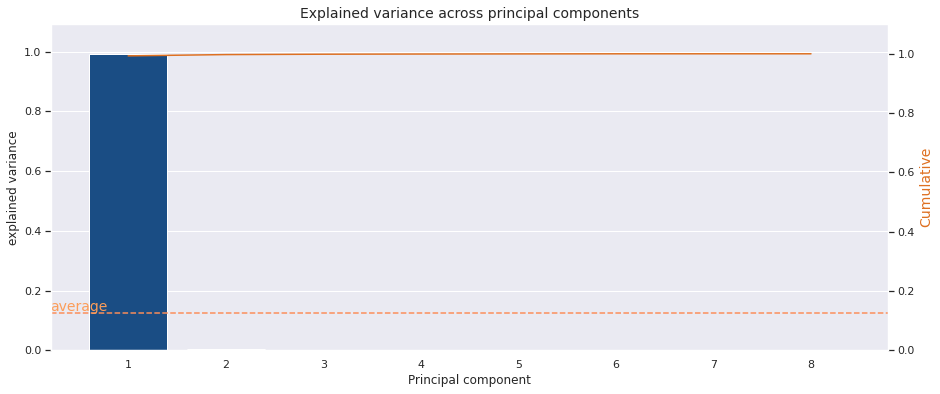

In [84]:
# limit plot to x PC
#limit = int(input("Limit scree plot to nth component (0 for all) > "))
limit = 0
if limit > 0:
    limit_df = limit
else:
    limit_df = n_components
    
df_explained_variance_limited = df_explained_variance.iloc[:limit_df,:]
    
    
# make scree plot
fig, ax1 = plt.subplots(figsize=(15,6))

ax1.set_title('Explained variance across principal components', fontsize=14)
ax1.set_xlabel('Principal component', fontsize=12)
ax1.set_ylabel('Explained variance', fontsize=12)

ax2 = sns.barplot(x=idx[:limit_df], y='explained variance', data=df_explained_variance_limited, palette='Blues_r')
ax2 = ax1.twinx()
ax2.grid(False)
ax2.set_ylabel('Cumulative', fontsize=14, color='#de7021')
ax2 = sns.lineplot(x=idx[:limit_df]-1, y='cumulative', data=df_explained_variance_limited, color='#de7021')

ax1.axhline(mean_explained_variance, ls='--', color='#fc8d59') 

#plot mean
ax1.text(-.8, mean_explained_variance+(mean_explained_variance*.05), "average", color='#fc9d59', fontsize=14)


# label y axis
max_y1 = max(df_explained_variance_limited.iloc[:,0])
max_y2 = max(df_explained_variance_limited.iloc[:,1])
ax1.set(ylim=(0, max_y1+max_y1*.1))
ax2.set(ylim=(0, max_y2+max_y2*.1))
plt.show()

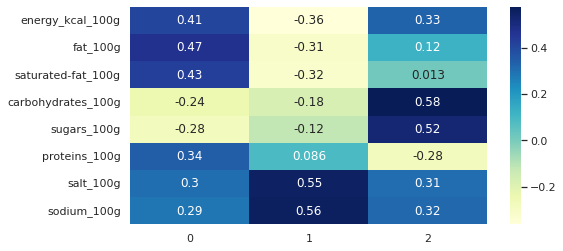

In [75]:
# check factor loading matrix
df_c = pd.DataFrame(pca.components_, columns=selected_features).T

# adjust y-axis size dynamically
size_yaxis = round(X_std.shape[1] * 0.5)
fig, ax = plt.subplots(figsize=(8,size_yaxis))# plot the first top_pc components
top_pc = 3
sns.heatmap(df_c.iloc[:,:top_pc], annot=True, cmap="YlGnBu", ax=ax)
plt.show()

Factor Loadings of 1st PC

Top 5 highest
----------------------------------------
fat_100g              0.471973
saturated-fat_100g    0.426067
energy_kcal_100g      0.410339
proteins_100g         0.343350
salt_100g             0.302349
Name: 0, dtype: float64 

Top 5 lowest
----------------------------------------
sugars_100g          -0.280101
carbohydrates_100g   -0.241096
sodium_100g           0.285379
salt_100g             0.302349
proteins_100g         0.343350
Name: 0, dtype: float64


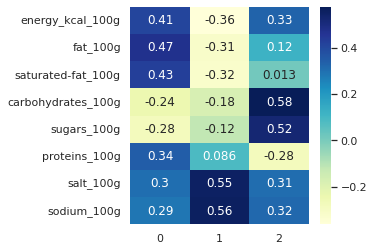

In [76]:
top_k = 5
print("Factor Loadings of 1st PC")
print('='*40,'\n')
print('Top {} highest'.format(top_k))
print('-'*40)
print(df_c.iloc[:,0].sort_values(ascending=False)[:top_k], '\n')

print('Top {} lowest'.format(top_k))
print('-'*40)
print(df_c.iloc[:,0].sort_values()[:top_k])

# Plot heatmap
size_xaxis = round(top_pc * 1.5)
size_yaxis = round(n_components * 0.5)

fig, ax = plt.subplots(figsize=(size_xaxis,size_yaxis))
sns.heatmap(df_c.iloc[:,:top_pc], annot=True, cmap="YlGnBu", ax=ax)
plt.show()

### Cercle de correlation

In [77]:
# https://stackoverflow.com/questions/37815987/plot-a-correlation-circle-in-python

,code,product_name,nutriscore_score,nutriscore_grade,pnns_groups_1,energy_kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,proteins_100g,salt_100g,sodium_100g,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,000000001231,Rillettes de sanglier au Chouchen,21.0,e,Salty snacks,325.0,29.00,11.000,0.000,0.000,16.00,1.60,0.640,92.607938,-16.135677,-5.769289,-4.073914,2.306036,-1.075123,-4.587295,-1.628355,0.022710
1,000000001576,Pur jus de pomme,0.0,b,Beverages,221.0,0.50,0.100,0.010,0.010,0.50,0.01,0.004,-14.109340,-1.146305,3.532617,22.349309,0.223000,3.108022,-1.483963,-0.285945,-0.014450
2,000000002218,Rillettes de canard au foie gras,14.0,d,Salty snacks,25.0,42.75,17.275,0.475,0.075,13.05,1.10,0.440,-205.538759,-24.802355,-28.056164,-27.386059,-12.004953,2.012529,3.425475,-0.447856,0.043339
3,00000006,Riz au lait,4.0,c,Milk and dairy products,150.0,5.30,3.400,22.000,13.000,3.30,0.12,0.048,-83.949926,16.100338,-6.040762,2.036272,3.031493,-1.075277,5.314773,-0.061479,0.001010
4,00000038,Pizza prosciutto,5.0,c,Composite foods,197.0,4.70,2.900,25.000,2.100,11.00,1.50,0.600,-36.929247,16.065588,3.473545,-1.051229,-1.447923,2.760938,-2.032838,0.325412,-0.012430


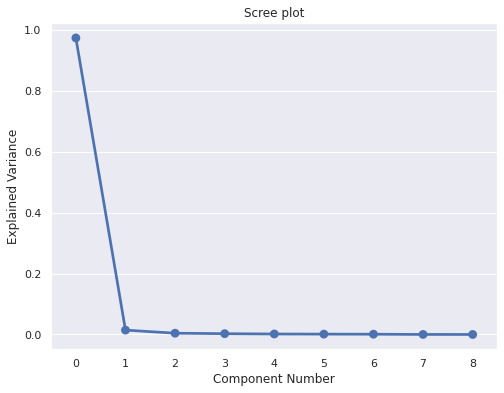

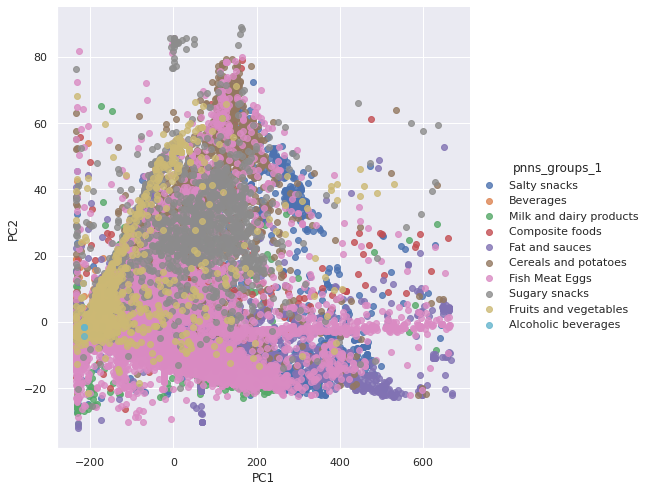

AttributeError: module 'seaborn' has no attribute 'plot'

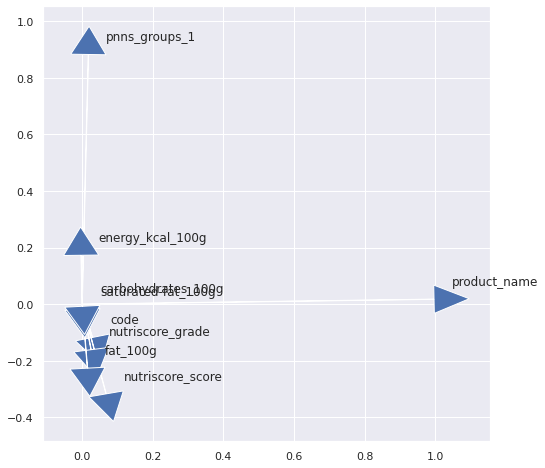

In [78]:
from sklearn.decomposition import PCA
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
 
#df = sns.load_dataset('iris')
 
n_components = len(num_cols)
 
# Do the PCA.
pca = PCA(n_components=n_components)
reduced = pca.fit_transform(df[num_cols])

# Append the principle components for each entry to the dataframe
for i in range(0, n_components):
    df['PC' + str(i + 1)] = reduced[:, i]

display(df.head())

# Do a scree plot
ind = np.arange(0, n_components)
(fig, ax) = plt.subplots(figsize=(8, 6))
sns.pointplot(x=ind, y=pca.explained_variance_ratio_)
ax.set_title('Scree plot')
ax.set_xticks(ind)
ax.set_xticklabels(ind)
ax.set_xlabel('Component Number')
ax.set_ylabel('Explained Variance')
plt.show()

# Show the points in terms of the first two PCs
g = sns.lmplot('PC1',
               'PC2',
               hue='pnns_groups_1',data=df,
               fit_reg=False,
               scatter=True,
               size=7)

plt.show()

# Plot a variable factor map for the first two dimensions.
(fig, ax) = plt.subplots(figsize=(8, 8))
for i in range(0, pca.components_.shape[1]):
    ax.arrow(0,
             0,  # Start the arrow at the origin
             pca.components_[0, i],  #0 for PC1
             pca.components_[1, i],  #1 for PC2
             head_width=0.1,
             head_length=0.1)

    plt.text(pca.components_[0, i] + 0.05,
             pca.components_[1, i] + 0.05,
             df.columns.values[i])


an = np.linspace(0, 2 * np.pi, 100)
sns.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale
plt.axis('equal')
ax.set_title('Variable factor map')
plt.show()

In [ ]:
# needing target aka nutriscore ?